In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import rasterio

import matplotlib.pyplot as plt


In [4]:
RASTER_DIR = "../data/raw"
OUTPUT_DIR = "../data/processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [5]:
raster_files = sorted(
    [f for f in glob(os.path.join(RASTER_DIR, "*.tif"))]
)

print(f"Found {len(raster_files)} raster layers")
raster_files


Found 45 raster layers


['../data/raw\\bd_0-5cm.tif',
 '../data/raw\\bd_15-30cm.tif',
 '../data/raw\\bd_30-60cm.tif',
 '../data/raw\\bd_5-15cm.tif',
 '../data/raw\\bd_60-100cm.tif',
 '../data/raw\\cec_0-5cm.tif',
 '../data/raw\\cec_15-30cm.tif',
 '../data/raw\\cec_30-60cm.tif',
 '../data/raw\\cec_5-15cm.tif',
 '../data/raw\\cec_60-100cm.tif',
 '../data/raw\\clay_0-5cm.tif',
 '../data/raw\\clay_15-30cm.tif',
 '../data/raw\\clay_30-60cm.tif',
 '../data/raw\\clay_5-15cm.tif',
 '../data/raw\\clay_60-100cm.tif',
 '../data/raw\\oc_0-5cm.tif',
 '../data/raw\\oc_15-30cm.tif',
 '../data/raw\\oc_30-60cm.tif',
 '../data/raw\\oc_5-15cm.tif',
 '../data/raw\\oc_60-100cm.tif',
 '../data/raw\\ph_0-5cm.tif',
 '../data/raw\\ph_15-30cm.tif',
 '../data/raw\\ph_30-60cm.tif',
 '../data/raw\\ph_5-15cm.tif',
 '../data/raw\\ph_60-100cm.tif',
 '../data/raw\\sand_0-5cm.tif',
 '../data/raw\\sand_15-30cm.tif',
 '../data/raw\\sand_30-60cm.tif',
 '../data/raw\\sand_5-15cm.tif',
 '../data/raw\\sand_60-100cm.tif',
 '../data/raw\\silt_0-5cm.t

In [6]:
with rasterio.open(raster_files[0]) as src:
    transform = src.transform
    crs = src.crs
    nodata = src.nodata
    height, width = src.shape

print("CRS:", crs)
print("Grid size:", height, "x", width)
print("NoData value:", nodata)


CRS: EPSG:4326
Grid size: 416 x 251
NoData value: -3.4028230607370965e+38


In [7]:
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(transform, rows, cols)

lon = np.array(xs).flatten()
lat = np.array(ys).flatten()

print("Total pixels:", len(lon))


Total pixels: 104416


In [8]:
data = {
    "lon": lon,
    "lat": lat
}

for path in raster_files:
    layer_name = os.path.basename(path).replace(".tif", "")
    
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float).flatten()
        if nodata is not None:
            arr[arr == nodata] = np.nan
    
    data[layer_name] = arr


In [9]:
df = pd.DataFrame(data)

df = df.dropna().reset_index(drop=True)

print("Valid soil pixels:", len(df))
df.head()


Valid soil pixels: 60847


,lon,lat,bd_0-5cm,bd_15-30cm,bd_30-60cm,bd_5-15cm,bd_60-100cm,cec_0-5cm,cec_15-30cm,cec_30-60cm,...,vmc15_0-5cm,vmc15_15-30cm,vmc15_30-60cm,vmc15_5-15cm,vmc15_60-100cm,vmc33_0-5cm,vmc33_15-30cm,vmc33_30-60cm,vmc33_5-15cm,vmc33_60-100cm
0,80.200606,9.831007,1.474551,1.251214,1.247321,1.268088,1.267176,9.696836,10.050234,8.765096,...,0.091413,0.094432,0.086927,0.089380,0.113287,0.139779,0.141806,0.140917,0.136302,0.164341
1,80.210034,9.831007,1.477457,1.254274,1.248992,1.271305,1.267237,9.696094,10.049469,8.764836,...,0.090660,0.093527,0.086824,0.088607,0.113083,0.138718,0.140517,0.140769,0.135216,0.164066
2,80.219462,9.831007,1.480309,1.257274,1.250630,1.274452,1.267298,9.695372,10.048725,8.764590,...,0.089930,0.092652,0.086723,0.087860,0.112884,0.137684,0.139267,0.140626,0.134159,0.163800
3,80.040334,9.821579,1.448169,1.197490,1.218059,1.210042,1.266133,9.706892,10.061332,8.765575,...,0.106922,0.113572,0.088722,0.105516,0.117233,0.161814,0.169483,0.143784,0.159180,0.169806
4,80.144039,9.821579,1.456341,1.232489,1.237070,1.248343,1.266806,9.701566,10.055047,8.766954,...,0.095993,0.100113,0.087610,0.094113,0.114533,0.146450,0.150088,0.141942,0.143163,0.166092


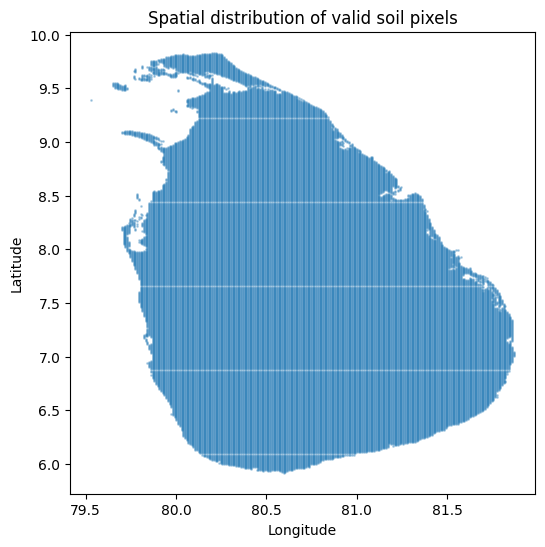

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.3)
plt.title("Spatial distribution of valid soil pixels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [11]:
output_path = os.path.join(OUTPUT_DIR, "soil_pixels_raw.csv")
df.to_csv(output_path, index=False)

print("Saved:", output_path)


Saved: ../data/processed\soil_pixels_raw.csv
